In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn  as sns

In [17]:
df=pd.read_csv("/content/healthcare_dataset (1).csv")
display(df.head())

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal


In [19]:
df['Medical Condition'].isnull()

,Medical Condition
0,False
1,False
2,False
3,False
4,False
...,...
55495,False
55496,False
55497,False
55498,False


In [20]:
print(df['Medical Condition'].value_counts())

Medical Condition
Arthritis       9308
Diabetes        9304
Hypertension    9245
Obesity         9231
Cancer          9227
Asthma          9185
Name: count, dtype: int64


In [21]:
df['Standardized_Medical_Condition'] = df['Medical Condition'].str.replace('ICD-10-', '')
print(df[['Medical Condition', 'Standardized_Medical_Condition']].head())

  Medical Condition Standardized_Medical_Condition
0            Cancer                         Cancer
1           Obesity                        Obesity
2           Obesity                        Obesity
3          Diabetes                       Diabetes
4            Cancer                         Cancer


In [30]:
df['Admission_Date'] = pd.to_datetime(df['Date of Admission'], errors='coerce')
df['Discharge_Date'] = pd.to_datetime(df['Discharge Date'], errors='coerce')

df['Hospital_Stay_Days'] = (df['Discharge_Date'] - df['Admission_Date']).dt.days
display(df[['Admission_Date', 'Discharge_Date', 'Hospital_Stay_Days']].head())

,Admission_Date,Discharge_Date,Hospital_Stay_Days
0,2024-01-31,2024-02-02,2
1,2019-08-20,2019-08-26,6
2,2022-09-22,2022-10-07,15
3,2020-11-18,2020-12-18,30
4,2022-09-19,2022-10-09,20


In [35]:
print("Summary Statistics for Billing Amount:")
display(df['Billing Amount'].describe())
print("\nSummary Statistics for Hospital Stay Days:")
display(df['Hospital_Stay_Days'].describe())

Summary Statistics for Billing Amount:


,Billing Amount
count,55500.000000
mean,25539.316097
std,14211.454431
min,-2008.492140
25%,13241.224652
50%,25538.069376
75%,37820.508436
max,52764.276736



Summary Statistics for Hospital Stay Days:


,Hospital_Stay_Days
count,55500.000000
mean,15.509009
std,8.659600
min,1.000000
25%,8.000000
50%,15.000000
75%,23.000000
max,30.000000


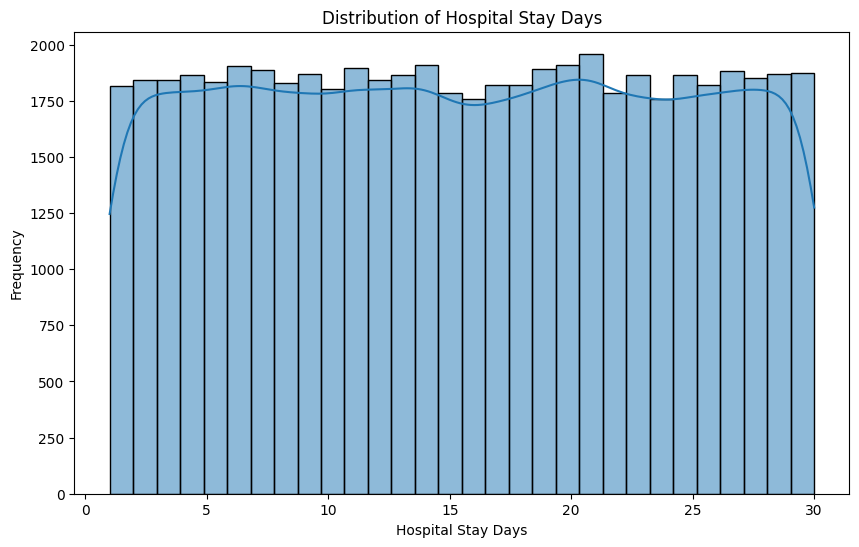

In [39]:

plt.figure(figsize=(10, 6))
sns.histplot(df['Hospital_Stay_Days'], kde=True, bins=30)
plt.title('Distribution of Hospital Stay Days')
plt.xlabel('Hospital Stay Days')
plt.ylabel('Frequency')
plt.grid
plt.show()

In [36]:
df['Hospital_Stay_Days']=(df['Discharge_Date']-df['Admission_Date']).dt.days
print(df['Billing Amount'].describe())
print(df['Hospital_Stay_Days'].describe())

count    55500.000000
mean     25539.316097
std      14211.454431
min      -2008.492140
25%      13241.224652
50%      25538.069376
75%      37820.508436
max      52764.276736
Name: Billing Amount, dtype: float64
count    55500.000000
mean        15.509009
std          8.659600
min          1.000000
25%          8.000000
50%         15.000000
75%         23.000000
max         30.000000
Name: Hospital_Stay_Days, dtype: float64
